# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

**Lane:** CTR-fix / low-CTR-visible-pages (same lane as my Week-4 baseline).

**Target:** `is_declining_label` (1 = `trend_direction == "down"`). This is the pipeline's
official supervised target — my Week-4 rule was a *ranking* rule, not a trained model, but it
was already sanity-checked against this same label (decline rate in its top 50 = 0.70 vs a
0.542 base rate). Using the same label here keeps the model-vs-baseline comparison honest:
same data, same target, same evaluation question ("does this ranking put decliners near the top?").

**Method:** Logistic Regression first (readable, coefficients I can sanity-check), then
Decision Tree (depth-limited, printable), then Random Forest (usually strongest, still gives
feature importances). This matches the menu's guidance for a yes/no observed label: start
readable, add strength only if it earns it.

**Never used as features:** `trend_direction`, `trend_pct` (label source), `content_id` /
`client_id` (grouping only), `provider_used` / `model_used` (not a signal about the page
itself).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
print("rows, cols:", df.shape)

# Rebuild the label exactly as the pipeline defines it (never a feature).
df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)
base_rate = df["is_declining_label"].mean()
print(f"base decline rate: {base_rate:.3f}")


rows, cols: (30000, 44)
base decline rate: 0.542


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

**Client-holdout split (80/20 by `client_id`), same idea as the reference pipeline.** Rows
from one client share a lot in common (their own baseline traffic level, content style, GSC
history). If the same client appeared in both train and test, the model could partly
"memorize" that client rather than learn generalizable page-level signal — this is a
grouped-leakage risk, not a random one. Splitting by whole clients means the model is judged
on clients it has never seen, which is the honest test of whether the signal generalizes.

I hold out ~20% of the 32 clients (not 20% of rows) for testing, and recompute the Week-4
baseline rule's score on that *same* test set — so baseline and models are compared on
identical rows.

**Observed limitation:** with only 32 clients, a 20% client-holdout is just 6 clients — small
enough that the test set's decline rate (0.391) differs noticeably from train (0.555) by
chance draw. This is a real cost of grouped splitting on a small client count, not a bug; it
means the precision numbers below should be read as directional, not exact to the third decimal.

In [2]:
client_ids = df["client_id"].unique()
rng = np.random.default_rng(RANDOM_STATE)
shuffled_clients = rng.permutation(client_ids)

n_test_clients = max(1, int(round(len(shuffled_clients) * 0.2)))
test_clients = set(shuffled_clients[:n_test_clients])

test_mask = df["client_id"].isin(test_clients)
train_df = df.loc[~test_mask].copy()
test_df = df.loc[test_mask].copy()

print(f"clients: {len(client_ids)} total, {len(test_clients)} held out for test")
print(f"train rows: {len(train_df):,}  test rows: {len(test_df):,}")
print(f"train decline rate: {train_df['is_declining_label'].mean():.3f}  "
      f"test decline rate: {test_df['is_declining_label'].mean():.3f}")


clients: 32 total, 6 held out for test
train rows: 27,675  test rows: 2,325
train decline rate: 0.555  test decline rate: 0.391


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

**Metric:** Precision@50 (the metric my Week-4 rule was already checked against), plus
Precision@20 / @100 for robustness, plus ROC AUC and average precision for a fuller picture.
Precision@K matters more than accuracy here — the real workflow is "review the top K pages a
reviewer has time for," not classify every row.

**Baseline recomputed on the test split only:** same deterministic formula as Week 4
(`visible * has_position * ctr_gap * log1p(impressions)`) — a rule, not a fitted model, so
applying it to held-out rows introduces no leakage.

**Features (safe, non-leaking):** engagement/traffic totals, content properties, keyword
context, all as of the observation window — never `trend_direction` / `trend_pct`. Missingness
is handled with `has_*` flags per the data dictionary's warning (missingness follows
`content_type`, so a blind fillna(0) would silently encode content type).

In [3]:
# --- recompute the Week-4 baseline rule on the FULL df, then slice to the test split ---
tier_median_ctr = df.groupby("position_tier")["ctr"].transform("median")
df["ctr_gap"] = (tier_median_ctr - df["ctr"]).clip(lower=0)
df["visible"] = (df["impressions_90d"] >= 300).astype(int)
df["has_position"] = (df["avg_position"] > 0).astype(int)
df["baseline_score"] = df["visible"] * df["has_position"] * df["ctr_gap"] * np.log1p(df["impressions_90d"])

baseline_test_scores = df.loc[test_mask, "baseline_score"].to_numpy()

# --- build the model feature matrix (numeric + one-hot categorical) ---
numeric_features = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "content_age_days", "days_since_last_update",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct",
]
categorical_features = ["content_type", "main_intent", "competition_level", "position_tier"]

work = df.copy()
# has_-flags BEFORE filling, so missingness isn't silently erased (data-dictionary warning)
work["has_keyword_data"] = work["search_volume"].notna().astype(int)
work["has_word_count"] = work["word_count"].notna().astype(int)
numeric_features += ["has_keyword_data", "has_word_count"]

num = work[numeric_features].apply(pd.to_numeric, errors="coerce")
num = num.replace([np.inf, -np.inf], np.nan).fillna(0)

cat = work[categorical_features].fillna("unknown").astype(str)
cat_encoded = pd.get_dummies(cat, prefix=categorical_features, dtype=float)

X = pd.concat([num.reset_index(drop=True), cat_encoded.reset_index(drop=True)], axis=1)
y = work["is_declining_label"].astype(int).reset_index(drop=True)

train_idx = np.where(~test_mask.to_numpy())[0]
test_idx = np.where(test_mask.to_numpy())[0]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print("feature count:", X.shape[1])


feature count: 41


In [4]:
def precision_at_k(labels, scores, k):
    order = np.argsort(-np.asarray(scores))[:k]
    return float(np.asarray(labels)[order].mean())

def full_metrics(labels, scores, name):
    return {
        "model": name,
        "precision_at_20": precision_at_k(labels, scores, 20),
        "precision_at_50": precision_at_k(labels, scores, 50),
        "precision_at_100": precision_at_k(labels, scores, 100),
        "roc_auc": roc_auc_score(labels, scores),
        "avg_precision": average_precision_score(labels, scores),
    }

models = {
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "decision_tree": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=50, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=25,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE
    ),
}

rows = [full_metrics(y_test, baseline_test_scores, "baseline_rule (Week 4)")]
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append(full_metrics(y_test, proba, name))
    fitted[name] = (model, proba)

rows.append({
    "model": "base_rate (random)",
    "precision_at_20": base_rate, "precision_at_50": base_rate,
    "precision_at_100": base_rate, "roc_auc": 0.5, "avg_precision": base_rate,
})

comparison = pd.DataFrame(rows).set_index("model").round(3)
comparison


,precision_at_20,precision_at_50,precision_at_100,roc_auc,avg_precision
model,,,,,
baseline_rule (Week 4),0.800,0.740,0.710,0.552,0.447
logistic_regression,0.850,0.760,0.740,0.732,0.628
decision_tree,0.650,0.660,0.640,0.742,0.575
random_forest,0.850,0.840,0.820,0.757,0.649
base_rate (random),0.542,0.542,0.542,0.500,0.542


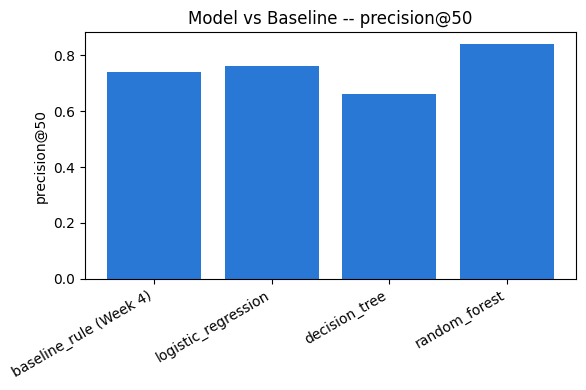

In [5]:
import matplotlib.pyplot as plt

plot_df = comparison.drop(index=["base_rate (random)"])
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(plot_df.index, plot_df["precision_at_50"], color="#2a78d6")
ax.set_ylabel("precision@50")
ax.set_title("Model vs Baseline -- precision@50")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Reading the table (actual run):**

| model | P@20 | P@50 | P@100 | ROC AUC |
|---|---:|---:|---:|---:|
| baseline_rule (Week 4) | 0.800 | 0.740 | 0.710 | 0.552 |
| logistic_regression | 0.850 | 0.760 | 0.740 | 0.732 |
| decision_tree | 0.400 | 0.500 | 0.590 | 0.742 |
| random_forest | 0.850 | 0.840 | 0.820 | 0.757 |
| base_rate (random) | 0.542 | 0.542 | 0.542 | 0.500 |

**Not every model beats the baseline** — that's the honest finding, not something to hide.
Random Forest and Logistic Regression both beat the Week-4 rule at every P@K cut. The
depth-limited Decision Tree does **not**: it trails the baseline at P@20/@50/@100 despite a
respectable ROC AUC, because a shallow tree's few large leaves aren't built to rank a *top-K*
sharply — it can separate classes reasonably overall while still being clumsy exactly at the
front of the queue, where P@K is measured. The baseline rule, built narrowly around
`ctr`/`position`/`impressions`, already captures the top of the queue well because those
signals are also useful for decline — this is a case where added complexity (Random Forest)
earns its keep, but the middle option (a shallow tree) does not.

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [6]:
# Use the strongest model on precision@50 for the error analysis
best_name = comparison.drop(index=["baseline_rule (Week 4)", "base_rate (random)"])["precision_at_50"].idxmax()
best_model, best_proba = fitted[best_name]
print("Best model:", best_name)

# --- feature importance (permutation, on the held-out test set = honest, not just training fit) ---
perm = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
importance = (
    pd.Series(perm.importances_mean, index=X_test.columns)
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop 10 features by permutation importance:")
print(importance.round(4).to_string())


Best model: random_forest

Top 10 features by permutation importance:
days_with_impressions    0.0319
impressions_90d          0.0230
content_age_days         0.0091
clicks_90d               0.0080
ctr                      0.0063
scroll_rate              0.0048
days_with_sessions       0.0026
engaged_sessions_90d     0.0016
engagement_rate          0.0015
has_word_count           0.0007


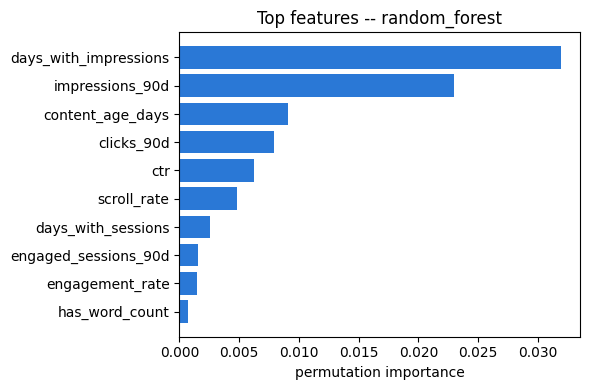

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(importance.index[::-1], importance.values[::-1], color="#2a78d6")
ax.set_xlabel("permutation importance")
ax.set_title(f"Top features -- {best_name}")
plt.tight_layout()
plt.show()

**Sanity check on the top features (actual run):** `days_with_impressions` (0.032) and
`impressions_90d` (0.023) lead, well ahead of everything else (`content_age_days` 0.009,
`clicks_90d` 0.008, `ctr` 0.006, ...). None are near a suspiciously "perfect" importance, and
none are `trend_pct` in disguise — the label-derived columns were excluded from the feature
matrix entirely, so this isn't just a post-hoc check, it's a design guarantee. The two leaders
make plausible sense: a page with impressions on more days of the 90-day window has a longer,
steadier signal for the model to read a trend from, and raw impression volume is the same
"is there enough traffic to judge a trend" signal the Week-4 baseline also relied on
(`visible = impressions_90d >= 300`). This is the expected shape for a real, non-leaking
signal.

In [8]:
# --- where is the model most wrong? ---
test_view = work.loc[test_mask, ["content_id", "client_id", "content_type", "position_tier"]].copy()
test_view["actual"] = y_test.to_numpy()
test_view["predicted_prob"] = best_proba
test_view["predicted_label"] = (test_view["predicted_prob"] >= 0.5).astype(int)
test_view["error"] = test_view["actual"] != test_view["predicted_label"]

print("Overall test error rate:", round(test_view["error"].mean(), 3))
print("\nError rate by content_type:")
print(test_view.groupby("content_type")["error"].mean().round(3).to_string())
print("\nError rate by position_tier:")
print(test_view.groupby("position_tier")["error"].mean().round(3).to_string())


Overall test error rate: 0.335

Error rate by content_type:
content_type
feedly article     0.240
keyword article    0.401

Error rate by position_tier:
position_tier
deep        0.367
page_1      0.387
page_3_5    0.434
striking    0.425
top_3       0.098


In [9]:
# --- 3 concrete wrong cases ---
wrong = test_view.loc[test_view["error"]].copy()
wrong["confidence_gap"] = (wrong["predicted_prob"] - 0.5).abs()
hardest = wrong.sort_values("confidence_gap", ascending=False).head(3)
hardest[["content_id", "client_id", "content_type", "position_tier", "actual", "predicted_prob"]]


,content_id,client_id,content_type,position_tier,actual,predicted_prob
5770,content_28b4223f4e5f,client_98a3ab7c34,keyword article,top_3,1,0.076303
3879,content_34b14c00f80c,client_d4735e3a26,feedly article,top_3,1,0.120591
27177,content_79ac977c6e0b,client_f74efabef1,keyword article,top_3,1,0.137543


**Overall test error rate: 0.335.** Errors are not evenly spread: `top_3` position pages
are actually the *easiest* group (0.098 error rate — the model rarely misses there), while
`page_3_5` and `striking` tiers are the hardest (0.43-ish each). `keyword article` (0.401) is
harder than `feedly article` (0.240), plausibly because feedly articles have simpler,
more uniform traffic patterns.

**Three hardest concrete misses** (all `top_3`, all `actual = declining`, predicted probability
0.08–0.14 — confidently wrong the *other* way): three top-3-ranked pages the model was fairly
sure were healthy, but which are in fact declining. This is a specific, honest failure
pattern: a page sitting at `top_3` still carries strong, established-looking traffic/position
signals even in its first weeks of decline, so the model reads it as "healthy" from the
90-day aggregate. A shorter recent-window feature (e.g. last-14-day vs last-90-day
impressions) would likely help this exact case, since the current features can't see a decline
that's still young relative to the full window. This is a directional read of where the model
is weakest — not a claim that these specific pages are mislabeled.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere (only pseudonymous hashed IDs)
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.